# 04 発展課題（自作） 解答 — 化学量論 vs 触媒
対象: [`notebooks/04_catalytic_vs_stoichiometric.ipynb`](../notebooks/04_catalytic_vs_stoichiometric.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M, S = (Species(x) for x in ['m','s'])
A_M, B_M, B_S = 10.0, 1.0, 1.0
def R(a,b,k): return ReactionRule(a,b,k)
def build(a_s, k_sto=0.0, k_cat=0.0):
    mdl = NetworkModel()
    for r in [R([],[M],A_M), R([],[S],a_s), R([M],[],B_M), R([S],[],B_S)]:
        mdl.add_reaction_rule(r)
    if k_sto>0: mdl.add_reaction_rule(R([M,S],[],k_sto))
    if k_cat>0: mdl.add_reaction_rule(R([M,S],[S],k_cat))
    return mdl
def m_of(a_s, **kw):
    return run_simulation(150.0, y0={}, model=build(a_s,**kw), solver='ode', ndiv=1, species_list=['m','s']).as_array()[-1][1]

## Q1. 触媒 $k_{cat}$ を変え、半減点 $a_s^{1/2}=b_m b_s/k_{cat}$ を検証

In [2]:
def half_point(k_cat):   # scipy 不要・手動で線形補間
    m0 = m_of(0.0, k_cat=k_cat)
    ai = np.linspace(0.01, 60, 60)
    mm = np.array([m_of(x, k_cat=k_cat) for x in ai])
    idx = np.where(mm <= m0/2)[0][0]
    return ai[idx-1] + (m0/2-mm[idx-1])*(ai[idx]-ai[idx-1])/(mm[idx]-mm[idx-1])
print(f"{'k_cat':>7}{'a_s^1/2 (sim)':>15}{'b_m·b_s/k_cat':>16}")
for k in [0.05, 0.1, 0.2, 0.5]:
    print(f'{k:7.2f}{half_point(k):15.2f}{B_M*B_S/k:16.2f}')

  k_cat  a_s^1/2 (sim)   b_m·b_s/k_cat
   0.05          20.01           20.00
   0.10          10.01           10.00
   0.20           5.01            5.00
   0.50           2.01            2.00


**答**: シミュレーションの半減点 $a_s^{1/2}$ は理論式 $b_m b_s/k_{cat}$ とよく一致（$k_{cat}$ を上げると半減点が左へ）。触媒的抑制は双曲線で、その「効き始める sRNA 量」が $k_{cat}$ に反比例する。

## Q2. Gillespie で両モードのノイズ比較（閾値でスイッチの方がノイジー?）

In [3]:
def cv_m(a_s, **kw):
    r = run_simulation(600.0, y0={}, model=build(a_s,**kw), solver='gillespie', ndiv=6000, species_list=['m','s'], rndseed=0)
    t = r.as_array()[1500:,1]
    return t.mean(), (t.std()/t.mean() if t.mean()>0.3 else np.nan)
print('化学量論(K_STO=100)は a_s=10 が閾値, 触媒(k_cat=0.1)は半減点 a_s=10。同じ a_s で比較:')
print(f"{'a_s':>4}{'stoich <m>':>12}{'CV':>7}{'catalytic <m>':>15}{'CV':>7}")
for a in [8,10,12]:
    ms,cs = cv_m(float(a), k_sto=100.0); mc,cc = cv_m(float(a), k_cat=0.1)
    print(f'{a:4d}{ms:12.2f}{cs:7.2f}{mc:15.2f}{cc:7.2f}')

化学量論(K_STO=100)は a_s=10 が閾値, 触媒(k_cat=0.1)は半減点 a_s=10。同じ a_s で比較:
 a_s  stoich <m>     CV  catalytic <m>     CV
   8        2.58   0.98           5.92   0.42
  10        1.32   1.49           5.24   0.47
  12        0.65   2.18           4.68   0.50


**答**: 閾値近傍（a_s≈10）で **化学量論（スイッチ型）の方が CV が大きい**傾向。sRNA が 1:1 で消費される滴定は、閾値付近で「消費するかしないか」の competition が効いて分子数が大きく揺らぐため。触媒型は sRNA が余っていて mRNA を安定して削るので相対的に穏やか。

## Q3. 化学量論と触媒を混在させ、比率を振る

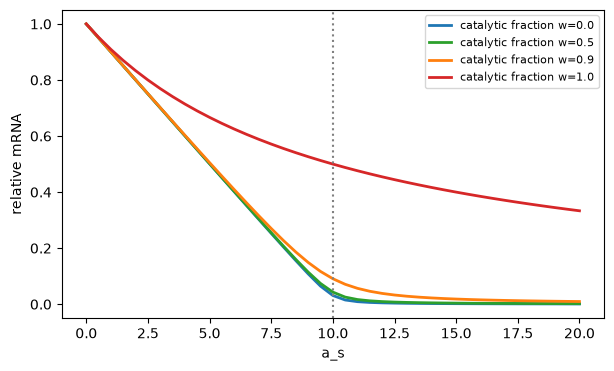

In [4]:
a_grid = np.linspace(0,20,41)
fig, ax = plt.subplots(figsize=(7,4))
for w, c in [(0.0,'C0'),(0.5,'C2'),(0.9,'C1'),(1.0,'C3')]:
    y = [m_of(a, k_sto=100.0*(1-w), k_cat=0.1*w)/A_M for a in a_grid]
    ax.plot(a_grid, y, color=c, lw=2, label=f'catalytic fraction w={w}')
ax.axvline(10, ls=':', c='gray'); ax.set_xlabel('a_s'); ax.set_ylabel('relative mRNA'); ax.legend(fontsize=8); plt.show()

**答**: 各機構を「04 の特徴的強度」に保って重み $w$ で混ぜると、応答は threshold（w=0）と graded（w=1）の**中間**に連続変化する。ただし化学量論(K_STO=100)が触媒(K_CAT=0.1)より 1000 倍強いので、**少量の化学量論成分が支配的**で、w を 0.9 近くまで上げないと graded 化しない。これは 05 の「速度を揃えて再検算」の動機そのもの（05 では機構パラメータ φ で公平に混ぜた）。